In [1]:
from hydra import compose, initialize
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import lognorm, norm
from matplotlib.ticker import FuncFormatter

In [2]:
with initialize(
    version_base=None, config_path="../configs"
):  # configs with data paths
    cfg = compose(
        config_name="config",
    )

In [3]:
## import Turner et al. data
turner_data = pd.read_csv(Path(cfg.paths.data_dir) / "variance_calculation" / "turner2019_variances.csv")

## Rename WetCHARTs ensemble members
# Rename WetCHARTs_WetCHARTs_Ens_N to WetCHARTs_N
for i in range(1, 19):  # 1 to 18
    old_name = f"WetCHARTs_WetCHARTs_Ens_{i}"
    new_name = f"WetCHARTs_{i-1}"  # 0-indexed
    turner_data['Dataset'] = turner_data['Dataset'].replace(old_name, new_name)

# Rename WetCHARTs_Annual_WetCHARTs_Ens_N to WetCHARTs_Annual_N
for i in range(1, 19):  # 1 to 18
    old_name = f"WetCHARTs_Annual_WetCHARTs_Ens_{i}"
    new_name = f"WetCHARTs_Annual_{i-1}"  # 0-indexed
    turner_data['Dataset'] = turner_data['Dataset'].replace(old_name, new_name)

In [4]:
# Verify the renaming
print("WetCHARTs entries:")
print(turner_data[turner_data['Dataset'].str.startswith('WetCHARTs_') & ~turner_data['Dataset'].str.startswith('WetCHARTs_Annual_')]['Dataset'].unique())
print("\nWetCHARTs_Annual entries:")
print(turner_data[turner_data['Dataset'].str.startswith('WetCHARTs_Annual_')]['Dataset'].unique())

WetCHARTs entries:
['WetCHARTs_0' 'WetCHARTs_1' 'WetCHARTs_2' 'WetCHARTs_3' 'WetCHARTs_4'
 'WetCHARTs_5' 'WetCHARTs_6' 'WetCHARTs_7' 'WetCHARTs_8' 'WetCHARTs_9'
 'WetCHARTs_10' 'WetCHARTs_11' 'WetCHARTs_12' 'WetCHARTs_13'
 'WetCHARTs_14' 'WetCHARTs_15' 'WetCHARTs_16' 'WetCHARTs_17']

WetCHARTs_Annual entries:
['WetCHARTs_Annual_0' 'WetCHARTs_Annual_1' 'WetCHARTs_Annual_2'
 'WetCHARTs_Annual_3' 'WetCHARTs_Annual_4' 'WetCHARTs_Annual_5'
 'WetCHARTs_Annual_6' 'WetCHARTs_Annual_7' 'WetCHARTs_Annual_8'
 'WetCHARTs_Annual_9' 'WetCHARTs_Annual_10' 'WetCHARTs_Annual_11'
 'WetCHARTs_Annual_12' 'WetCHARTs_Annual_13' 'WetCHARTs_Annual_14'
 'WetCHARTs_Annual_15' 'WetCHARTs_Annual_16' 'WetCHARTs_Annual_17']


# Histogram of variances with distribution fits


OH:
  Lognormal parameters: shape (σ) = 0.2532, scale (median) = 6.9969
  Normal parameters: μ = 7.2335, σ = 1.9267

Biomass Burning:
  Lognormal parameters: shape (σ) = 0.2169, scale (median) = 38.5633
  Normal parameters: μ = 39.4743, σ = 8.4313

Monthly Wetlands:
  Lognormal parameters: shape (σ) = 0.8384, scale (median) = 80.4269
  Normal parameters: μ = 128.3565, σ = 172.2934

Annual Wetlands:
  Lognormal parameters: shape (σ) = 0.9073, scale (median) = 29.4548
  Normal parameters: μ = 48.9383, σ = 65.4690


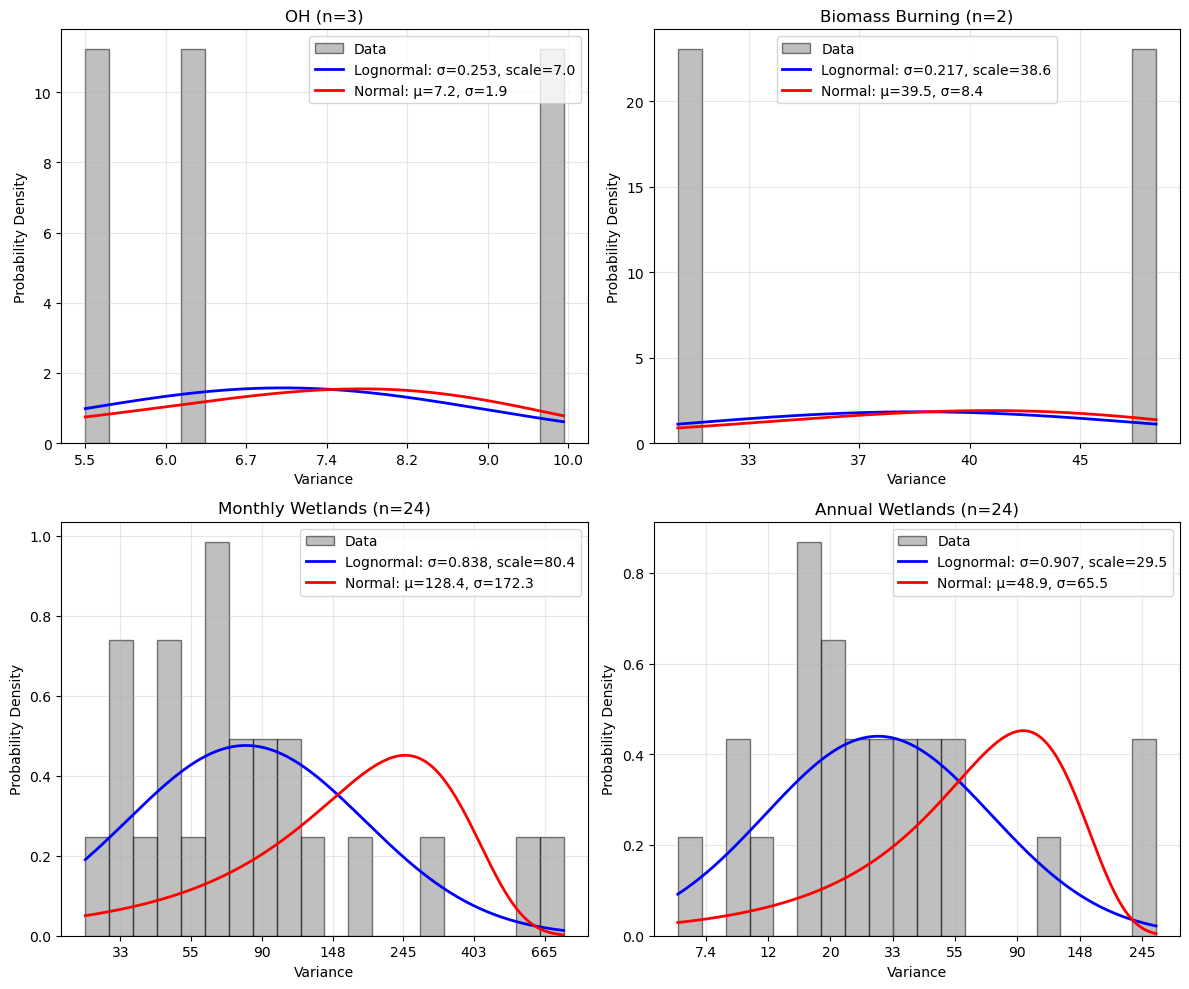

In [5]:
## Define source categories
categories = {
    'OH': turner_data[turner_data['Dataset'].str.startswith('oh_')],
    'Biomass Burning': turner_data[turner_data['Dataset'].isin(['GFED', 'EDGAR'])],
    'Monthly Wetlands': turner_data[
        (turner_data['Dataset'].str.startswith('WetCHARTs_') & ~turner_data['Dataset'].str.startswith('WetCHARTs_Annual_')) |
        (turner_data['Dataset'].str.startswith('WetCHIMP_') & ~turner_data['Dataset'].str.startswith('WetCHIMP_Annual_'))
    ],
    'Annual Wetlands': turner_data[
        turner_data['Dataset'].str.startswith('WetCHARTs_Annual_') |
        turner_data['Dataset'].str.startswith('WetCHIMP_Annual_')
    ]
}

## Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (category_name, data) in enumerate(categories.items()):
    ax = axes[idx]
    
    # Get variances and convert to log space
    variances = data['Variance'].values
    log_variances = np.log(variances)
    
    # Create histogram
    counts, bins, patches = ax.hist(log_variances, bins=20, alpha=0.5, 
                                      color='gray', edgecolor='black', 
                                      density=True, label='Data')
    
    # Fit lognormal distribution (in original variance space)
    shape, loc, scale = lognorm.fit(variances, floc=0)
    
    # Fit normal distribution (in original variance space, NOT log space)
    mu_normal, std_normal = norm.fit(variances)
    
    # Generate x values for plotting fitted distributions in log space
    x_range = np.linspace(log_variances.min(), log_variances.max(), 200)
    x_original = np.exp(x_range)  # Convert back to original variance scale
    
    # Plot lognormal fit (blue) - fitted in variance space, plotted in log space
    # PDF of Y=ln(X) where X~lognorm is: f_Y(y) = f_X(e^y) * e^y
    lognorm_pdf = lognorm.pdf(x_original, shape, loc, scale)
    # Transform to log space: multiply by Jacobian |dx/dy| = e^y
    lognorm_pdf_log = lognorm_pdf * x_original
    ax.plot(x_range, lognorm_pdf_log, 'b-', linewidth=2, 
            label=f'Lognormal: σ={shape:.3f}, scale={scale:.1f}')
    
    # Plot normal fit (red) - fitted in variance space, plotted in log space
    # For normal distribution fitted in variance space, transform PDF to log space
    normal_pdf = norm.pdf(x_original, mu_normal, std_normal)
    # Transform to log space: multiply by Jacobian |dx/dy| = e^y
    normal_pdf_log = normal_pdf * x_original
    ax.plot(x_range, normal_pdf_log, 'r-', linewidth=2, 
            label=f'Normal: μ={mu_normal:.1f}, σ={std_normal:.1f}')
    
    # Labels and title
    ax.set_xlabel('Variance')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{category_name} (n={len(variances)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Format x-axis to show actual variance values instead of log values
    def log_to_variance(x, pos):
        """Convert log value to actual variance for tick labels"""
        val = np.exp(x)
        if val < 10:
            return f'{val:.1f}'  # Show 1 decimal for values below 10
        elif val < 1000:
            return f'{val:.0f}'
        else:
            return f'{val:,.0f}'
    
    ax.xaxis.set_major_formatter(FuncFormatter(log_to_variance))
    
    # Print parameters
    print(f"\n{category_name}:")
    print(f"  Lognormal parameters: shape (σ) = {shape:.4f}, scale (median) = {scale:.4f}")
    print(f"  Normal parameters: μ = {mu_normal:.4f}, σ = {std_normal:.4f}")

plt.tight_layout()
plt.show()